# Top-level imports and mount to google drive

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Access our shared folder so we can use our downloaded data

In [ ]:
# Define the path to specific folder in MyDrive
specific_folder_path = '/content/drive/MyDrive/DD2424_project_2026'

# Check if the folder exists and list its contents
if os.path.exists(specific_folder_path):
    print(f"Contents of '{specific_folder_path}':")
    for item in os.listdir(specific_folder_path):
        print(item)
else:
    print(f"The folder '{specific_folder_path}' does not exist. Please check the path.")

Contents of '/content/drive/MyDrive/DD2424_project_2026':
Data
E-level.ipynb
E-level-multiclass.ipynb
checkpoints
teacher_metrics.json
teacher_summary.txt
distillation_results_log.txt
distillation_sweep_results.json
baseline_results.txt
Kopia av baseline_results.txt
Kopia av teacher_metrics.json
Kopia av distillation_results_log.txt
Kopia av teacher_summary.txt
Kopia av distillation_sweep_results.json
A_level_distillation_with_metrics.ipynb
more_experiments.ipynb
A-level-distillation.ipynb


### Untarring `annotations.tar` and `images.tar`

We will extract the contents of the `annotations.tar` and `images.tar` files.  Extract these into a temporary location within the Colab environment, typically under `/content/` to avoid cluttering Google Drive.

In [ ]:
import os

# Define the path to the Data folder within project directory
project_data_path = os.path.join(specific_folder_path, 'Data')

# Define the base directory where extracted files will be stored
extracted_base_path = '/content/DD2424_project_2026_extracted'

# Create subdirectories for annotations and images
annotations_output_path = os.path.join(extracted_base_path, 'annotations')
images_output_path = os.path.join(extracted_base_path, 'images')

os.makedirs(annotations_output_path, exist_ok=True)
os.makedirs(images_output_path, exist_ok=True)

print(f"Created extraction directory: {annotations_output_path}")
print(f"Created extraction directory: {images_output_path}")


Created extraction directory: /content/DD2424_project_2026_extracted/annotations
Created extraction directory: /content/DD2424_project_2026_extracted/images


In [ ]:
# Path to the annotations tar file
annotations_tar_file = os.path.join(project_data_path, 'annotations.tar')

# Untar annotations.tar into the 'annotations' subdirectory
print(f"Extracting {annotations_tar_file} to {annotations_output_path}...")
!tar -xf {annotations_tar_file} -C {annotations_output_path}
print("Extraction complete for annotations.tar")

# List contents to verify
print(f"Contents of {annotations_output_path}:")
!ls {annotations_output_path}

Extracting /content/drive/MyDrive/DD2424_project_2026/Data/annotations.tar to /content/DD2424_project_2026_extracted/annotations...
Extraction complete for annotations.tar
Contents of /content/DD2424_project_2026_extracted/annotations:
annotations


In [ ]:
# Path to the images tar file
images_tar_file = os.path.join(project_data_path, 'images.tar')

# Untar images.tar into the 'images' subdirectory
print(f"Extracting {images_tar_file} to {images_output_path}...")
!tar -xf {images_tar_file} -C {images_output_path}
print("Extraction complete for images.tar")

# List contents to verify
print(f"Contents of {images_output_path}:")
!ls {images_output_path}

Extracting /content/drive/MyDrive/DD2424_project_2026/Data/images.tar to /content/DD2424_project_2026_extracted/images...
Extraction complete for images.tar
Contents of /content/DD2424_project_2026_extracted/images:
images


# Access, and split the data up for binary classification dog vs cat


Excerpt from the '/annotations/annotations/README.txt' file:


```
We have created a 37 category pet dataset with roughly 200 images for each class.
The images have a large variations in scale, pose and lighting. All images have an
associated ground truth annotation of breed, head ROI, and pixel
level trimap segmentation.

Contents:
--------
trimaps/ 	Trimap annotations for every image in the dataset
		Pixel Annotations: 1: Foreground 2:Background 3: Not classified
xmls/		Head bounding box annotations in PASCAL VOC Format

list.txt	Combined list of all images in the dataset
		Each entry in the file is of following nature:
		Image CLASS-ID SPECIES BREED ID
		ID: 1:37 Class ids
		SPECIES: 1:Cat 2:Dog
		BREED ID: 1-25:Cat 1:12:Dog
		All images with 1st letter as captial are cat images while
		images with small first letter are dog images.
    trainval.txt	Files describing splits used in the paper.However,
    test.txt	you are encouraged to try random splits.
```





In [ ]:
def get_breeds_for_multiclass():
    breeds = {} # key: file prefix, val: breed id
    with open(f"{annotations_output_path}/annotations/list.txt", "r") as f:
        for line in f:
            # Skip comments or empty lines
            if line.startswith("#") or not line.strip():
                continue
            parts = line.split()
            image_name = parts[0]
            breed_id = parts[3]
            breeds[image_name] = breed_id
    return breeds
print("Mapping cat and dog breeds...")
breeds = get_breeds_for_multiclass()

Mapping cat and dog breeds...


In [ ]:
file_names = os.listdir("/content/DD2424_project_2026_extracted/images/images/")
path = "/content/DD2424_project_2026_extracted/images/images/"

In [ ]:
# Re-generating the labels dictionary to fix the TypeError
labels = {}
for file_name in file_names:
    split_name = file_name.split('.')
    base_name, extension = split_name[0], split_name[1]
    if extension == 'mat': # skip matlab files
        continue
    if base_name in breeds.keys():
        labels[file_name] = breeds[base_name]

# Create a list of filenames that actually have labels
labeled_filenames = list(labels.keys())

print(f'Number of labeled images: {len(labeled_filenames)}')
print(f'Sample labels keys: {list(labels.keys())[:5]}')

Number of labeled images: 7349
Sample labels keys: ['Bengal_168.jpg', 'boxer_81.jpg', 'chihuahua_89.jpg', 'keeshond_101.jpg', 'english_setter_101.jpg']


In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os

class PetDataset(Dataset):
    def __init__(self, image_dir, filenames, labels_dict, transform=None):
        self.image_dir = image_dir
        self.filenames = list(filenames)
        self.labels_dict = labels_dict
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_name = self.filenames[idx]
        img_path = os.path.join(self.image_dir, img_name)

        # Load image
        image = Image.open(img_path).convert('RGB')

        # Get label (1-37 from list.txt, map to 0-36 for PyTorch)
        label = int(self.labels_dict[img_name]) - 1

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(tensor, title=None):
    # Convert from Tensor to Numpy
    image = tensor.cpu().numpy().transpose((1, 2, 0))

    # Undo the ImageNet Normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean

    # Clip to stay between 0 and 1 (standard for matplotlib)
    image = np.clip(image, 0, 1)

    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

# Process the images: Ensure they are the same size, etc.

We use our torch dataset class along with dataloader to follow torch convention, also so that we can load our data in batches in a way that doesn't crash our gpu. Dataset class is used to standardize how we fetch individual samples from our directory along with an associated label. DataLoader wraps this class and returns batches of torch images along with their labels!

Number of training images: 5143
Number of validation images: 1103
Number of test images: 1103
Displaying a sample image from the training set:


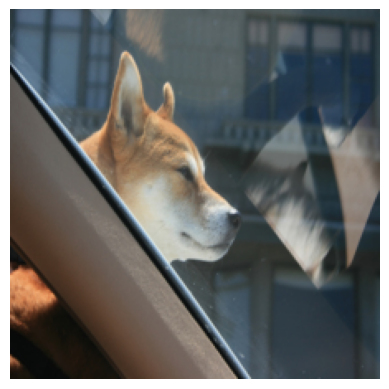

In [ ]:
import torch
import torchvision.transforms as transforms
from PIL import Image # Pillow is used by torchvision to load images
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.model_selection import train_test_split


# Define transformations (STANDARD FOR CIFAR)
transform_pipeline = transforms.Compose([
      transforms.Resize((224, 224)), # Resize image to 224x224 pixels (common input size for CNNs)
      transforms.ToTensor(),        # Convert PIL Image or numpy.ndarray to a PyTorch Tensor
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize with ImageNet mean/std
  ])

# Split data into training, validation, and test sets
train_filenames, test_filenames = train_test_split(labeled_filenames, test_size=0.15, random_state=42)
train_filenames, val_filenames = train_test_split(train_filenames, test_size=(0.15/0.85), random_state=42) # Split remaining 85% into train and validation

print(f"Number of training images: {len(train_filenames)}")
print(f"Number of validation images: {len(val_filenames)}")
print(f"Number of test images: {len(test_filenames)}")

# Create Dataset instances for each split
train_dataset = PetDataset(image_dir=path, filenames=train_filenames, labels_dict=labels, transform=transform_pipeline)
val_dataset = PetDataset(image_dir=path, filenames=val_filenames, labels_dict=labels, transform=transform_pipeline)
test_dataset = PetDataset(image_dir=path, filenames=test_filenames, labels_dict=labels, transform=transform_pipeline)

# Create DataLoader instances for each split
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False) # No need to shuffle validation/test sets
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Display a sample image from the training loader
print("Displaying a sample image from the training set:")
for images, batch_labels in train_loader:
    imshow(images[0])
    break

# Let's train the BIG resnet 50. Our teacher model.

In [ ]:
import torch.nn as nn
from torchvision import models

# Load the pre-trained ResNet18
model = models.resnet50(weights='DEFAULT')

# Freeze all params in model

In [ ]:
for param in model.parameters():
    param.requires_grad = False # We're telling autograd not to track and compute gradients for these weights

# Unfreeze linear layer

In [ ]:
# Check how many inputs the last layer had
num_ftrs = model.fc.in_features

# Replace the last layer, is automatically unfrozen
model.fc = nn.Linear(num_ftrs, 37)

# Move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Set optimizer - ADAM

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

# Only optimize the parameters of the final layer
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

### Load Latest Checkpoint (if available)
This cell checks if any checkpoints exist for the ResNet50 model. If so, it loads the most recent one to resume training or to use the model without retraining from scratch.

In [ ]:
import glob
import os

checkpoint_dir = specific_folder_path + "/checkpoints/"

# Ensure the checkpoint directory exists
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

# List all checkpoint files
list_of_files = glob.glob(os.path.join(checkpoint_dir, 'resnet_50_checkpoint_*.pth'))

if list_of_files:
    # Find the latest checkpoint based on its number in the filename
    latest_file = max(list_of_files, key=lambda f: int(f.split('_')[-1].split('.')[0]))
    print(f"Loading latest checkpoint: {latest_file}")
    model.load_state_dict(torch.load(latest_file))
    print("Model weights loaded successfully!")
else:
    print("No existing checkpoints found. Starting training from scratch.")


Loading latest checkpoint: /content/drive/MyDrive/DD2424_project_2026/checkpoints/resnet_50_checkpoint_5.pth
Model weights loaded successfully!


# Test my loaded big model

In [ ]:
# Test Evaluation
model.eval()
test_correct, test_total = 0, 0
with torch.no_grad():
      for images, labels_t in test_loader:
          images, labels_t = images.to(device), labels_t.to(device)
          outputs = model(images)
          _, predicted = torch.max(outputs.data, 1)
          test_total += labels_t.size(0)
          test_correct += (predicted == labels_t).sum().item()
test_acc = 100. * test_correct / test_total
print("test accuracy for fully trained loaded resnet 50 model", test_acc)


# TRAIN THE MODEL!!!

In [ ]:
from tqdm import tqdm
import time # Import time for measuring training duration
import json # For saving metrics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
num_epochs = 10
checkpoint = 1
checkpoint_path = specific_folder_path + "/checkpoints/"

teacher_metrics = [] # To store metrics for the teacher model

start_time_teacher = time.time() # Start timing for teacher training

for epoch in range(num_epochs):
    model.train() # set to training mode
    running_loss = 0.0 # to track total loss for this epoch
    correct = 0
    total = 0
    if epoch % 2 == 0:
      # checkpoint in case we mess up the
      checkpoint_name = f"resnet_50_checkpoint_{checkpoint}.pth"
      save_path = os.path.join(checkpoint_path, checkpoint_name)
      torch.save(model.state_dict(), save_path)
      checkpoint += 1
    for inputs, labels in tqdm(train_loader, desc=f"Teacher Training Epoch: {epoch}"):

      inputs, labels = inputs.to(device), labels.to(device) # move to gpu

      output = model(inputs) # forward

      loss = criterion(output, labels) # compute loss

      optimizer.zero_grad() # reset optimizer for this batch

      loss.backward() # backprop

      optimizer.step() # adjust weights

      running_loss += loss.item() * inputs.size(0) # because loss.item() returns average across all items.

      # get predicted class labels:
      _, predicted = torch.max(output, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

    running_val_loss = 0
    correct_val = 0
    total_val = 0
    model.eval()
    with torch.no_grad():
        for inputs, labels_t in val_loader:
          inputs, labels_t = inputs.to(device), labels_t.to(device)
          output = model(inputs)
          loss = criterion(output, labels_t)
          running_val_loss += loss.item() * inputs.size(0)
          _, predicted = torch.max(output, 1)
          total_val += labels_t.size(0)
          correct_val += (predicted == labels_t).sum().item()

    # epoch stats
    train_loss_avg = running_loss / len(train_loader)
    train_acc = 100. * correct / total
    val_acc = 100. * correct_val / total_val
    print(f"\nSummary Epoch {epoch+1}: Train Loss: {train_loss_avg:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    # for plots
    teacher_metrics.append({
        'epoch': epoch + 1,
        'train_loss': train_loss_avg,
        'train_acc': train_acc,
        'val_acc': val_acc
    })

end_time_teacher = time.time()
total_teacher_training_time = end_time_teacher - start_time_teacher
print(f"Total Teacher Training Time: {total_teacher_training_time:.2f} seconds")

 #save metrics
teacher_metrics_log_file = os.path.join(specific_folder_path, "teacher_metrics.json")
with open(teacher_metrics_log_file, 'w') as f:
    json.dump(teacher_metrics, f, indent=4)
print(f"Saved teacher metrics to {teacher_metrics_log_file}")

model.eval()
test_correct_teacher, test_total_teacher = 0, 0
with torch.no_grad():
      for images, labels_t in test_loader:
          images, labels_t = images.to(device), labels_t.to(device)
          outputs = model(images)
          _, predicted = torch.max(outputs.data, 1)
          test_total_teacher += labels_t.size(0)
          test_correct_teacher += (predicted == labels_t).sum().item()
test_acc_teacher = 100. * test_correct_teacher / test_total_teacher
print(f"Final Teacher Test Accuracy: {test_acc_teacher:.2f}%")
with open(os.path.join(specific_folder_path, "teacher_summary.txt"), "w") as f:
    f.write(f"Total Teacher Training Time: {total_teacher_training_time:.2f} seconds\n")
    f.write(f"Final Teacher Test Accuracy: {test_acc_teacher:.2f}%\n")


#BEGIN DISTILLATION

In [ ]:
import torch
import torch.nn.functional as F

def distillation_loss(student_logits, teacher_logits, true_labels, temperature, alpha):
    # per the hinton paper
    hard_loss = F.cross_entropy(student_logits, true_labels)
    soft_teacher = F.softmax(teacher_logits / temperature, dim=1)
    soft_student = F.log_softmax(student_logits / temperature, dim=1)
    soft_loss = F.kl_div(soft_student, soft_teacher, reduction='batchmean')
    soft_loss = soft_loss * (temperature ** 2)
    total_loss = (alpha * hard_loss) + ((1 - alpha) * soft_loss)
    return total_loss

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm
import time

teacher_model = model
teacher_model.eval()

# freeze the entire Teacher model so it doesn't accidentally learn/change
for param in teacher_model.parameters():
    param.requires_grad = False

# student set up
student_model = models.resnet18(weights='DEFAULT')
num_ftrs_student = student_model.fc.in_features
student_model.fc = nn.Linear(num_ftrs_student, 37)
student_model = student_model.to(device)
student_optimizer = optim.Adam(student_model.parameters(), lr=0.001)


T = 2.0       # best temp
alpha = 0.9   # best alpha
num_epochs = 10
results_file = os.path.join(specific_folder_path, "distillation_results_log.txt")

with open(results_file, "a") as f:
    f.write(f"\n=================================================\n")
    f.write(f"NEW DISTILLATION RUN | T={T} | Alpha={alpha}\n")
    f.write(f"=================================================\n")
print(f"Starting Distillation (T={T}, Alpha={alpha}). Logging to Drive...")

start_time = time.time()
for epoch in range(num_epochs):
    student_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(train_loader, desc=f"Distillation Epoch: {epoch}"):
        inputs, labels = inputs.to(device), labels.to(device)
        with torch.no_grad():
            teacher_logits = teacher_model(inputs)
        student_logits = student_model(inputs)

        # ---- combined loss ------
        loss = distillation_loss(student_logits, teacher_logits, labels, temperature=T, alpha=alpha)

        # - backpropr only for student -----
        student_optimizer.zero_grad()
        loss.backward()
        student_optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(student_logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # --- Validation Phase ---
    student_model.eval()
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels_t in val_loader:
            inputs, labels_t = inputs.to(device), labels_t.to(device)
            output = student_model(inputs)
            _, predicted = torch.max(output, 1)
            total_val += labels_t.size(0)
            correct_val += (predicted == labels_t).sum().item()
    train_loss_avg = running_loss / total
    train_acc = 100. * correct / total
    val_acc = 100. * correct_val / total_val

    epoch_summary = f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss_avg:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%"
    print(epoch_summary)

    # in case of crash
    with open(results_file, "a") as f:
        f.write(epoch_summary + "\n")

end_time = time.time()
total_distillation_time = end_time - start_time
print(f"Total Distillation Training Time: {total_distillation_time:.2f} seconds")

with open(results_file, "a") as f:
    f.write(f"Total Distillation Training Time: {total_distillation_time:.2f} seconds\n")

# ------ final eval ---------
print("\nRunning Final Test Set Evaluation...")
student_model.eval()
test_correct, test_total = 0, 0

with torch.no_grad():
    for images, labels_t in test_loader:
        images, labels_t = images.to(device), labels_t.to(device)
        outputs = student_model(images)
        _, predicted = torch.max(outputs, 1)
        test_total += labels_t.size(0)
        test_correct += (predicted == labels_t).sum().item()

test_acc = 100. * test_correct / test_total

final_summary = f"\nFINAL DISTILLED TEST ACCURACY: {test_acc:.2f}%\n"
print(final_summary)

with open(results_file, "a") as f:
    f.write(final_summary)
student_save_path = os.path.join(specific_folder_path, "checkpoints", f"student_resnet18_distilled_T{T}.pth")
torch.save(student_model.state_dict(), student_save_path)
print(f"Saved Distilled Student weights to: {student_save_path}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


Starting Distillation (T=2.0, Alpha=0.9). Logging to Drive...


Distillation Epoch: 0: 100%|██████████| 161/161 [00:57<00:00,  2.80it/s]


Epoch [1/10] | Train Loss: 1.6252 | Train Acc: 55.05% | Val Acc: 52.77%


...

Epoch [8/10] | Train Loss: 0.0943 | Train Acc: 99.92% | Val Acc: 83.68%


Distillation Epoch: 8: 100%|██████████| 161/161 [00:58<00:00,  2.77it/s]


Epoch [9/10] | Train Loss: 0.0863 | Train Acc: 99.94% | Val Acc: 82.68%


Distillation Epoch: 9: 100%|██████████| 161/161 [00:57<00:00,  2.80it/s]


Epoch [10/10] | Train Loss: 0.0813 | Train Acc: 99.88% | Val Acc: 82.68%
Total Distillation Training Time: 648.25 seconds

Running Final Test Set Evaluation...

FINAL DISTILLED TEST ACCURACY: 86.22%

Saved Distilled Student weights to: /content/drive/MyDrive/DD2424_project_2026/checkpoints/student_resnet18_distilled_T2.0.pth


In [ ]:
import json
import os

def run_distillation_experiment(T, alpha, num_epochs=10):
    print(f"\nStarting Experiment: T={T}, alpha={alpha}")

    # Re-initialize student for each experiment to ensure fairness
    student_model = models.resnet18(weights='DEFAULT')
    student_model.fc = nn.Linear(student_model.fc.in_features, 37)
    student_model = student_model.to(device)
    optimizer = optim.Adam(student_model.parameters(), lr=0.001)

    stats = {'train_loss': [], 'val_acc': [], 'test_acc': 0, 'time': 0}
    start_time = time.time()

    for epoch in range(num_epochs):
        # --------- train ----------
        student_model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            with torch.no_grad():
                teacher_logits = teacher_model(inputs)

            student_logits = student_model(inputs)
            loss = distillation_loss(student_logits, teacher_logits, labels, T, alpha)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # ------Validation---------
        student_model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = student_model(inputs)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        stats['train_loss'].append(running_loss / len(train_loader))
        stats['val_acc'].append(val_acc)
        print(f"Epoch {epoch+1}: Val Acc {val_acc:.2f}%")

    stats['time'] = time.time() - start_time

    # -------- Final Test ------------
    student_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = student_model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    stats['test_acc'] = 100 * correct / total

    return stats
temperatures = [2.0, 5.0, 10.0]
alphas = [0.1, 0.5, 0.9]
all_results = {}

for t in temperatures:
    for a in alphas:
        exp_id = f"T{t}_A{a}"
        all_results[exp_id] = run_distillation_experiment(t, a)
with open(os.path.join(specific_folder_path, 'distillation_sweep_results.json'), 'w') as f:
    json.dump(all_results, f)

# Train a standard Resnet 18 with transfer learning final layer as baseline

In [ ]:
model = models.resnet18(weights='DEFAULT')
for param in model.parameters():
  param.requires_grad = False
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 37)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm
import time

print("Initializing Baseline Model (ResNet-18)...")
model = models.resnet18(weights='DEFAULT')


for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 37)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

num_epochs = 10
results_file = os.path.join(specific_folder_path, "baseline_results.txt")

with open(results_file, "a") as f:
    f.write(f"\n=================================================\n")
    f.write(f"Standard baseline run, RESNET-18")
    f.write(f"\n=================================================\n")

start_time = time.time()
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(train_loader, desc=f"Baseline Epoch: {epoch}"):
        inputs, labels = inputs.to(device), labels.to(device)

        # ----Forward pass ------
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # --- Validation Phase ---
    model.eval()
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels_t in val_loader:
            inputs, labels_t = inputs.to(device), labels_t.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total_val += labels_t.size(0)
            correct_val += (predicted == labels_t).sum().item()
    train_loss_avg = running_loss / total
    train_acc = 100. * correct / total
    val_acc = 100. * correct_val / total_val

    epoch_summary = f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss_avg:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%"
    print(epoch_summary)
    with open(results_file, "a") as f:
        f.write(epoch_summary + "\n")

end_time = time.time()
total_training_time = end_time - start_time
print(f"Total Baseline Training Time: {total_training_time:.2f} seconds")

with open(results_file, "a") as f:
    f.write(f"Total Baseline Training Time: {total_training_time:.2f} seconds\n")

print("\nRunning Final Test Set Evaluation...")
model.eval()
test_correct, test_total = 0, 0

with torch.no_grad():
    for images, labels_t in test_loader:
        images, labels_t = images.to(device), labels_t.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        test_total += labels_t.size(0)
        test_correct += (predicted == labels_t).sum().item()

test_acc = 100. * test_correct / test_total

final_summary = f"\nFINAL BASELINE TEST ACCURACY: {test_acc:.2f}%\n"
print(final_summary)

with open(results_file, "a") as f:
    f.write(final_summary)
baseline_save_path = os.path.join(specific_folder_path, "checkpoints", "baseline_resnet18.pth")
torch.save(model.state_dict(), baseline_save_path)
print(f"Saved Baseline ResNet-18 weights to: {baseline_save_path}")

Initializing Baseline Model (ResNet-18)...


Baseline Epoch: 0: 100%|██████████| 161/161 [00:32<00:00,  4.99it/s]


Epoch [1/10] | Train Loss: 1.6993 | Train Acc: 56.41% | Val Acc: 76.70%


Baseline Epoch: 1: 100%|██████████| 161/161 [00:32<00:00,  4.99it/s]


Epoch [2/10] | Train Loss: 0.7737 | Train Acc: 81.06% | Val Acc: 81.23%


...

Epoch [8/10] | Train Loss: 0.3507 | Train Acc: 89.93% | Val Acc: 83.41%


Baseline Epoch: 8: 100%|██████████| 161/161 [00:32<00:00,  4.90it/s]


Epoch [9/10] | Train Loss: 0.3235 | Train Acc: 90.98% | Val Acc: 83.05%


Baseline Epoch: 9: 100%|██████████| 161/161 [00:33<00:00,  4.82it/s]


Epoch [10/10] | Train Loss: 0.3063 | Train Acc: 91.13% | Val Acc: 83.95%
Total Baseline Training Time: 405.16 seconds

Running Final Test Set Evaluation...

FINAL BASELINE TEST ACCURACY: 86.04%

Saved Baseline ResNet-18 weights to: /content/drive/MyDrive/DD2424_project_2026/checkpoints/baseline_resnet18.pth
